In [1]:
%reset

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import torch.nn as nn

In [3]:
directory = '/home/choudhar/HNNs/data/'
folder = "double_well_20/"
dynamics = "double_well"

In [11]:
directory = '/home/choudhar/HNNs/data/'
folder = "mass_spring_10/"
dynamics = "mass_spring"

In [3]:
directory = '/home/choudhar/HNNs/data/'
folder = "non_sep_10/"
dynamics = "non_sep"

In [19]:
directory = '/home/choudhar/HNNs/data/'
folder = "henon_heiles_filt/"
dynamics = "henon_heiles"

In [4]:
directory = '/home/choudhar/HNNs/data/'
folder = "coupled_ho_10/"
dynamics = "coupled_ho"

In [4]:
# train_file_path = directory + folder + dynamics+"_train_h.pt"
# val_file_path = directory + folder + dynamics+"_val_h.pt"
# test_file_path = directory + folder + dynamics+"_test_h.pt"
# noisy_train_file_path = directory + folder + "noisy_" + dynamics + "_train_h.pt"
# noisy_val_file_path = directory + folder + "noisy_" + dynamics + "_val_h.pt"
# noisy_test_file_path = directory + folder + "noisy_" + dynamics + "_test_h.pt"

In [20]:
train_file_path = directory + folder + dynamics+"_train.pt"
val_file_path = directory + folder + dynamics+"_val.pt"
test_file_path = directory + folder + dynamics+"_test.pt"
noisy_train_file_path = directory + folder + "noisy_" + dynamics + "_train.pt"
noisy_val_file_path = directory + folder + "noisy_" + dynamics + "_val.pt"
noisy_test_file_path = directory + folder + "noisy_" + dynamics + "_test.pt"

In [21]:
train_noisy = torch.load(noisy_train_file_path)
val_noisy = torch.load(noisy_val_file_path)
test_noisy = torch.load(noisy_val_file_path)

train = torch.load(train_file_path)
val = torch.load(val_file_path)
test = torch.load(val_file_path)

In [22]:
def mass_spring(y, args, kargs):
    q = y[:, 0]
    p = y[:, 1]
    dq_dt = p
    dp_dt = -q
    return torch.stack((dq_dt, dp_dt), dim=-1)

In [23]:
def double_well(y, args, kargs):
    q = y[:, 0]
    p = y[:, 1]
    dq_dt = p
    dp_dt = q - q**3
    return torch.stack((dq_dt, dp_dt), dim=-1)

In [24]:
def non_sep(y, args, kargs):
    q = y[:, 0]
    p = y[:, 1]
    dq_dt = p - p**3
    dp_dt = -q - p**2
    return torch.stack((dq_dt, dp_dt), dim=-1)

In [25]:
def henon_heiles(y, args, kargs):
    q1, q2, p1, p2 = y[:, 0], y[:, 1], y[:, 2], y[:, 3]
    
    dq1 = p1
    dq2 = p2
    dp1 = -q1 - 2 * q1 * q2
    dp2 = -q2 - q1**2 + q2**2
    
    return torch.stack((dq1, dq2, dp1, dp2), dim=-1)

In [26]:
# Dynamics for the non-separable Hamiltonian system
def coupled_ho(y, args, kargs):
    alpha = args
    #alpha = 0.5
    q, p = y[:, 0], y[:, 1]
    dqdt = p + alpha * q
    dpdt = -q - alpha * p
    return torch.stack((dqdt, dpdt), dim=-1)

In [27]:
# def forward_ode(y_tensor, args, kargs):

#     model = args[0]
#     i = kargs[0]
    
        
#     with torch.enable_grad():

#         y = y_tensor.clone().detach().requires_grad_(True)

#         h = model(y)
    
#         grad_h = torch.autograd.grad(outputs=h.sum(), inputs=y, create_graph=True, retain_graph=True, allow_unused=True)[0]
#         #print("grad h: ", grad_h)
#         dq_dt = grad_h[:, 1]
#         dp_dt = -grad_h[:, 0]

#     return torch.stack((dq_dt, dp_dt), dim=-1)

def forward_ode(y_tensor, args, kargs):

    model = args[0]
    i = kargs[0]
    br_i = y_tensor.shape[1]//2
        
    with torch.enable_grad():

        y = y_tensor.clone().detach().requires_grad_(True)

        h = model(y)

    
        grad_h = torch.autograd.grad(outputs=h.sum(), inputs=y, create_graph=True, retain_graph=True, allow_unused=True)[0]

        #print("grad h: ", grad_h)
        dq_dt = grad_h[:, br_i:2*br_i]
        dp_dt = -grad_h[:, 0:br_i]

    return torch.cat((dq_dt, dp_dt), dim=-1)

In [ ]:
# class HamiltonianNN(nn.Module):
#     # For now the input data is passed as init parameters
#     def __init__(self, model_specs):
#         super(HamiltonianNN, self).__init__()

#         # Create a list of linear layers based on layer_sizes
#         layer_sizes = model_specs[0]
#         self.layers = nn.ModuleList()
#         self.dropout_layers = nn.ModuleList()
#         self.RANDOM_SEED = 0
#         for i in range(len(layer_sizes) - 2):  # All layers except the last one
#             self.layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1], bias=True))

#             self.dropout_layers.append(nn.Dropout(p=0.2))
        
#         # Last layer without bias
#         self.layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1], bias=False))

#     def forward(self, x):
#         for i, layer in enumerate(self.layers[:-1]):
#             x = layer(x)
#             x = torch.tanh(x)
#             if i < len(self.dropout_layers):
#                 x = self.dropout_layers[i](x)
#         x = self.layers[-1](x)
#         return x

In [28]:
class HamiltonianNN(nn.Module):
    # For now the input data is passed as init parameters
    def __init__(self, model_specs):
        super(HamiltonianNN, self).__init__()

        # Create a list of linear layers based on layer_sizes
        layer_sizes = model_specs[0]
        self.layers = nn.ModuleList()
        self.dropout_layers = nn.ModuleList()
        self.RANDOM_SEED = 0
        for i in range(len(layer_sizes) - 2):  # All layers except the last one
            self.layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1], bias=True))

            self.dropout_layers.append(nn.Dropout(p=0.2))
        
        # Last layer without bias
        self.layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1], bias=False))

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = torch.tanh(x)
            if i < len(self.dropout_layers):
                x = self.dropout_layers[i](x)
        x = self.layers[-1](x)
        return x

In [29]:
def get_dynamics_plot(y, model, dynamics, args):
    
    pred_dyn = forward_ode(y, (model,), (0,))
    true_dyn = dynamics(y, args, None)
    return pred_dyn, true_dyn

In [30]:
def rk2_step(dyn, y, dt, dynamics, args, kargs):
    h = dt
    i = kargs[0]
    br_i = y.shape[1]//2
    q, p = y[:, 0:br_i], y[:, br_i:2*br_i]


    dy1 = dynamics(y, args, kargs)
    q1 = q + 0.5 * dy1[:, 0:br_i] * h
    p1 = p + 0.5 * dy1[:, br_i:2*br_i] * h

    y1 = torch.cat((q1, p1), dim=-1)
    dy2 = dynamics(y1, args, kargs)

    q_new = q + dy2[:, 0:br_i] * h
    p_new = p + dy2[:, br_i:2*br_i] * h
    return torch.cat((q_new, p_new), dim=-1)



def im_step(dyn, y, dt, dynamics, iterations, y_init, args, kargs):
    h = dt
    br_i = y.shape[1] // 2
    q, p = y[:, 0:br_i], y[:, br_i:2 * br_i]
    
    y_init_concat = torch.cat((y_init[:, 0:br_i], y_init[:, br_i:2*br_i]), dim=-1)  # Shape [batch, 2]
    f_init = dynamics(y_init_concat, args, kargs)  # Compute dynamics at initial point
    
    q_new = q + 0.5 * h * f_init[:, 0:br_i]  # Shape [batch, 1]
    p_new = p + 0.5 * h * f_init[:, br_i:2*br_i]  # Shape [batch, 1]

    for _ in range(iterations):
        mid_q = 0.5 * (q + q_new)  # Shape [batch, q_shape]
        mid_p = 0.5 * (p + p_new)  # Shape [batch, p_shape]
        
        mid_concat = torch.cat((mid_q, mid_p), dim=-1)  # Ensure [batch, 2*q_shape]
        f_mid = dynamics(mid_concat, args, kargs)  # Compute dynamics at midpoint
        
        q_new = q + h * f_mid[:, 0:br_i]  # Shape [batch, q_shape]
        p_new = p + h * f_mid[:, br_i:2*br_i]  # Shape [batch, p_shape]

    return torch.cat((q_new, p_new), dim=-1)  # Final shape [batch, 2*q_shape]


def solve_ivp_custom_ms_im(dynamics, dyn, pred, y_data, t_span, dt, shooting_segment_length, number_of_shooting_segments, args, iters):
    t0, t1 = t_span
    shooting_nodes = [y_data[:, i * shooting_segment_length, :] for i in range(number_of_shooting_segments + 1)]
    segments = []
    cont_errors = []
    
    for seg in range(number_of_shooting_segments):
        y_seg = shooting_nodes[seg]
        seg_states = [y_seg]
        
        for j in range(1, shooting_segment_length + 1):
            step_index = seg * shooting_segment_length + j
            if pred=="True":
                y_ = rk2_step(dyn, y_seg, dt, dynamics, args, kargs=(step_index,))
            else:
                y_ = y_data[:, step_index, :]
            y_next = im_step(dyn, y_seg, dt, dynamics, iters, y_, args, kargs=(step_index,))
            seg_states.append(y_next)
            y_seg = y_next
        
        seg_states = torch.stack(seg_states, dim=1)
        segments.append(seg_states)
        
        cont_error = y_seg - shooting_nodes[seg + 1]
        cont_errors.append(cont_error)
    
    full_traj = segments[0]
    for seg in segments[1:]:
        full_traj = torch.cat((full_traj, seg[:, 1:, :]), dim=1)
    
    return full_traj, cont_errors

In [42]:
def rk2_step(dyn, y, dt, dynamics, args, kargs):
    h = dt
    i = kargs[0]
    q, p = y[:, 0], y[:, 1]

    #y = torch.stack((q, p), dim=-1)  # Shape: (batch_size, 2)

    #print(q.shape)

    dy1 = dynamics(y, args, kargs)
    q1 = q + 0.5 * dy1[:, 0] * h
    p1 = p + 0.5 * dy1[:, 1] * h

    y1 = torch.stack((q1, p1), dim=-1)  # Shape: (batch_size, 2)
    dy2 = dynamics(y1, args, kargs)

    q_new = q + dy2[:, 0] * h
    p_new = p + dy2[:, 1] * h
    return torch.stack((q_new, p_new), dim=-1)


def sv_step(dyn, y, dt, dynamics, iterations, y_init, args, kargs):
    h = dt
    q, p = y[:, 0], y[:, 1]
    i = kargs[0]

    p_half = p + 0.5 * h * dynamics(torch.stack((q, y_init[:, 1]), dim=-1), args, kargs)[:, 1]
    for _ in range(iterations):
        p_half = p + 0.5 * h * dynamics(torch.stack((q, p_half), dim=-1), args, kargs)[:, 1]

    q_half = q + 0.5 * h * dynamics(torch.stack((y_init[:, 0], p_half), dim=-1), args, kargs)[:, 0]
    for _ in range(iterations):
        q_half = q + 0.5 * h * dynamics(torch.stack((q_half, p), dim=-1), args, kargs)[:, 0]

    q_new = q + h * dynamics(torch.stack((q_half, p_half), dim=-1), args, kargs)[:, 0]
    p_new = p_half + 0.5 * h * dynamics(torch.stack((q_new, p_half), dim=-1), args, kargs)[:, 1]

    return torch.stack((q_new, p_new), dim=-1)


def solve_ivp_custom_ms_sv(dynamics, dyn, y_batch, t_span, dt, args, iters):
    #t = torch.arange(0, T, dt)
    batch_size = y_batch.shape[0]
    t0, t1 = t_span
    t = 0.1
    if t0 > t1:
        dt = -dt
    num_steps = int((t1 - t0) / t)
    #y0_batch = noisy_obs[:, 0, :]
    ys_batch = []
    #print(y0_batch.shape)
    #print("y len: ",y_batch.shape[1])
    #_y = torch.zeros((batch_size, t_vals.shape[0], 2), dtype=torch.float32, requires_grad=False, device=y_init.device)
    #_y[:, 0, :] = y_init.clone()

    for i in range(0, num_steps):
        if i == 0:
            y = y_batch[:,0,:]
            #y.requires_grad_(True)
            ys_batch.append(y)
        else:
            y = y_batch[:,len(ys_batch)-1,:]
            #print("goes in: ", len(ys_batch)-1)
            #y.requires_grad_(True)
            ys_batch[-1] = y
        for j in range(1, int(t/dt)+1):
            #y = noisy_obs[:, i-1, :]  # Use the noisy observation at the current step
            y = ys_batch[-1]
            y_ = rk2_step(dyn, y, dt, dynamics, args, kargs=(j,))
            y_next = sv_step(dyn, y, dt, dynamics, iters, y_, args, kargs=(j,))
            #print(y_next.requires_grad)
            ys_batch.append(y_next)
        #print(y_next.shape)
    ys_batch = torch.stack(ys_batch, dim=1)
    #print(ys_batch.requires_grad)
    #print("return len: ", ys_batch.shape[1])
    return ys_batch

In [ ]:
# def solve_ivp_custom_ms(dynamics, dyn, y_batch, t_span, dt, args, iters):
#     #t = torch.arange(0, T, dt)
#     batch_size = y_batch.shape[0]
#     t0, t1 = t_span
#     t = 0.1
#     if t0 > t1:
#         dt = -dt
#     num_steps = int((t1 - t0) / t)
#     #y0_batch = noisy_obs[:, 0, :]
#     ys_batch = []
#     #print(y0_batch.shape)
#     #print("y len: ",y_batch.shape[1])
#     #_y = torch.zeros((batch_size, t_vals.shape[0], 2), dtype=torch.float32, requires_grad=False, device=y_init.device)
#     #_y[:, 0, :] = y_init.clone()

#     for i in range(0, num_steps):
#         if i == 0:
#             y = y_batch[:,0,:]
#             #y.requires_grad_(True)
#             ys_batch.append(y)
#         else:
#             y = y_batch[:,len(ys_batch)-1,:]
#             #print("goes in: ", len(ys_batch)-1)
#             #y.requires_grad_(True)
#             ys_batch[-1] = y
#         for j in range(1, int(t/dt)+1):
#             #y = noisy_obs[:, i-1, :]  # Use the noisy observation at the current step
#             y = ys_batch[-1]
#             y_ = rk2_step(dyn, y, dt, dynamics, args, kargs=(j,))
#             y_next = sv_step(dyn, y, dt, dynamics, iters, y_, args, kargs=(j,))
#             #print(y_next.requires_grad)
#             ys_batch.append(y_next)
#         #print(y_next.shape)
#     ys_batch = torch.stack(ys_batch, dim=1)
#     #print(ys_batch.requires_grad)
#     #print("return len: ", ys_batch.shape[1])
#     return ys_batch

In [31]:
def gen_trajs(noisy_val_trajs, model):
    #pq0_batch = true_val_trajectories[0:128, 0, :]
    dt_solve=0.01
    #T=20.0
    T=10.0
    pq0_batch = noisy_val_trajs[0:20, :, :]
    pred = "True"
    sim_len = 2
    sims = 500
    y_pred_batch, const_errors = solve_ivp_custom_ms_im(forward_ode, "forward", pred, pq0_batch, (0, T), dt_solve,
                sim_len, sims, args=(model,), iters=6)
    #y_pred_batch = solve_ivp_custom_ms_sv(forward_ode, "forward", pq0_batch, (0, T), dt_solve, args=(model,), iters=5)
    return y_pred_batch

In [32]:
# Load the model
#model = torch.load('/home/choudhar/HNNs/models/model_0_ms.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_adjoint_0_ms_test.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_mass_spring_0.0_adjoint.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_coupled_ho_0.0_adjoint_True_7_im.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_double_well_0.0_adjoint_True_7_im.pt')
model = torch.load('/home/choudhar/HNNs/models/model_0_henon_heiles_0.0_adjoint_True_7_im.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_coupled_ho_0.0_adjoint_ms_im.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_coupled_ho_sv.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_coupled_ho_ss_im.pt')
#model  = torch.load('/home/choudhar/HNNs/models/model_0_double_well.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_ns.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_dw_adjoint.pt')
#model = torch.load('/home/choudhar/HNNs/models/model_0_hh_adjoint.pt')
model.eval()  # Set the model to evaluation mode


HamiltonianNN(
  (layers): ModuleList(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Linear(in_features=16, out_features=32, bias=True)
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): Linear(in_features=16, out_features=1, bias=False)
  )
  (dropout_layers): ModuleList(
    (0-2): 3 x Dropout(p=0.2, inplace=False)
  )
)

In [33]:
pred_trajs = gen_trajs(test, model)

In [19]:
pred_trajs.shape

torch.Size([20, 2001, 2])

In [22]:
h = torch.zeros((6, test.shape[1]))
p_0 = test[0:1000, 0, 1]
#p_1 = test[0:1000, 0, 3]
q_0 = test[0:1000, 0, 0]
#q_1 = test[0:1000, 0, 1]

In [34]:
#HEnon Heiles
h = torch.zeros((6, test.shape[1]))
p_0 = test[0:1000, 0, 2]
p_1 = test[0:1000, 0, 3]
q_0 = test[0:1000, 0, 0]
q_1 = test[0:1000, 0, 1]

In [19]:
x = q_0.unsqueeze(dim=1)
x.shape

torch.Size([1000, 1])

In [38]:

### Hamiltonian Spring Mass ###
#true_h_0 = (0.5*p_0**2) + (0.5*q_0**2)

### Hamiltonian Double Well ###
#true_h_0 = (0.5*(p_0**2) + 0.25*(q_0**4) - 0.5*(q_0**2))

### Hamiltonian coupled oscillator ###
#alpha = 0.5
#true_h_0 = (0.5*p_0**2) + (0.5*q_0**2) + alpha*q_0*p_0

### Hamiltonian Henon Heiles ###
true_h_0 = (0.5*(p_0**2 + p_1**2) + 0.5*(q_0**2 + q_1**2) + (q_0**2)*(q_1)  -((q_1**3)/3))

#Henon Heiles
pred_h_0 = model(torch.stack((q_0, q_1, p_0, p_1), dim=1)).squeeze()

#pred_h_0 = model(torch.stack((q_0, p_0), dim=1)).squeeze()

offsets = (pred_h_0.detach().numpy() - true_h_0.numpy())

offset = np.mean(offsets)

# for i in range(test_noisy.shape[1]):
#     pred_h = model(test_noisy[0:6,i,:]).squeeze()
#     offset = pred_h - h_0
#     h[:, i] = pred_h - offset

In [39]:
offsets

array([-2.134889 , -2.1333184, -2.1292412, -2.1352527, -2.1305525,
       -2.1310878, -2.1378736, -2.1358345, -2.136707 , -2.1366842,
       -2.1371603, -2.1339676, -2.131667 , -2.1339204, -2.1321688,
       -2.13479  , -2.1273007, -2.1344707, -2.1359282, -2.1339598,
       -2.1339207, -2.1341746, -2.1378217, -2.1367054, -2.131597 ,
       -2.139285 , -2.1304693, -2.1330225, -2.1304069, -2.1335497,
       -2.1364374, -2.135946 , -2.1293168, -2.133514 , -2.129791 ,
       -2.1311305, -2.1273553, -2.1378033, -2.1307359, -2.1286414,
       -2.1363535, -2.1256623, -2.1381598, -2.135306 , -2.1346757,
       -2.1356297, -2.1278367, -2.1289062, -2.1294537, -2.126987 ,
       -2.1294618, -2.135133 , -2.1335826, -2.1320148, -2.1373112,
       -2.1273353, -2.1346228, -2.1307936, -2.1307569, -2.136915 ,
       -2.129664 , -2.1359377, -2.136289 , -2.1370804, -2.1330929,
       -2.134676 , -2.1341665, -2.1362908, -2.1348658, -2.132686 ,
       -2.126487 , -2.137266 , -2.132707 , -2.1250353, -2.1333

In [51]:
# h_t = np.ones((3,2))
# print(h_t.shape)
# a = np.ones((6,2))* true_h_0[0:6].detach().numpy() [:, np.newaxis]
# print(a)

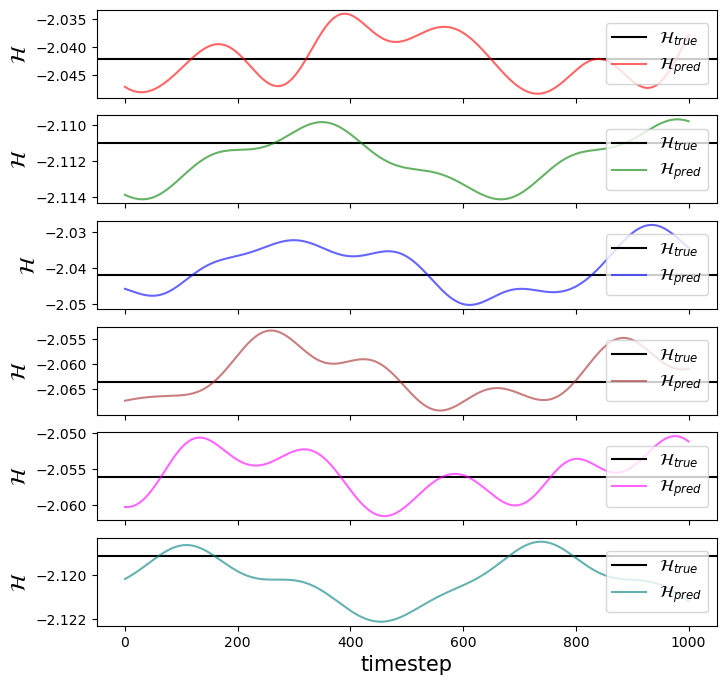

In [42]:
def create_subplots(h_pred, h_true):

  num_subplots = 6
  fig, axes = plt.subplots(nrows=num_subplots, figsize=(8, 8), sharex=True)

  colors = ['red', 'green', 'blue', 'brown', 'magenta', 'teal']

  for i in range(num_subplots):
    #axes[i].plot(np.arange(h.shape[1]), h2[i,:], color='black', alpha=0.6, label='$\mathcal{H}_{noisy}$')
    axes[i].axhline(y = h_true[i], xmin=0, xmax=h_pred.shape[1], color = 'black', label='$\mathcal{H}_{true}$')
    axes[i].plot(np.arange(h_pred.shape[1]), h_pred[i,:], color=colors[i], alpha=0.6, label='$\mathcal{H}_{pred}$')
    axes[i].set_ylabel("$\mathcal{H}$", fontsize=15)
    axes[i].legend(fontsize=12, loc="right")
  axes[5].set_xlabel("timestep", fontsize=15)

  plt.show()

# Example usage:
# Replace h1 and h2 with your actual data
#h1 = np.random.rand(6, 100)
#h2 = np.random.rand(6, 100)

pred_h_t = np.zeros((6,pred_trajs.shape[1]))

for i in range(pred_trajs.shape[1]):
    
    h_t_pred = model(test[6:12,i,:]).squeeze()
    pred_h_t[:,i] = h_t_pred.detach().numpy()
#p_t = pred_trajs[0:6, :, 1]
#q_t = pred_trajs[0:6, :, 0]

### Harmonic Oscillator ###
#h_t = (0.5*p_t**2) + (0.5*q_t**2)

### Double Well ###
#h_t = (0.5*(p_t**2) + 0.25*(q_t**4) - 0.5*(q_t**2))

### Coupled Oscillator ###
#pred_h_t = (0.5*p_t**2) + (0.5*q_t**2) + alpha*p_t*q_t
#h_t = (0.5*q_t**2) + (q_t*p_t**2) + (0.5*p_t**2) - (0.25*p_t**4) 
true_h_t = true_h_0[6:12]
create_subplots(pred_h_t, true_h_t + offset)

In [44]:
t_fut = 100

In [48]:
# alpha = 0.5
# pred_dyn, true_dyn = get_dynamics_plot(test_noisy[:, 0, :], model, coupled_ho, alpha)
# pred_dyn_fut, true_dyn_fut = get_dynamics_plot(test_noisy[:, t_fut, :], model, coupled_ho, alpha)

#pred_dyn, true_dyn = get_dynamics_plot(test_noisy[:, 0, :], model, henon_heiles, None)
#pred_dyn_fut, true_dyn_fut = get_dynamics_plot(test_noisy[:, t_fut, :], model, henon_heiles, None)

#pred_dyn, true_dyn = get_dynamics_plot(test_noisy[:, 0, :], model, mass_spring, alpha)
#pred_dyn_fut, true_dyn_fut = get_dynamics_plot(test_noisy[:, t_fut, :], model, mass_spring, alpha)


pred_dyn, true_dyn = get_dynamics_plot(test_noisy[:, 0, :], model, henon_heiles, None)
pred_dyn_fut, true_dyn_fut = get_dynamics_plot(test_noisy[:, t_fut, :], model, henon_heiles, None)

In [49]:
pred_dyn_np = pred_dyn.detach().numpy()
pred_dyn_np_fut = pred_dyn_fut.detach().numpy()
true_dyn_np = true_dyn.detach().numpy()
true_dyn_np_fut = true_dyn_fut.detach().numpy()

In [55]:
plot_res = (torch.abs(pred_dyn[:, 0] - true_dyn[:, 0]) + torch.abs(pred_dyn[:, 1] - true_dyn[:, 1]))
plot_res_fut = (torch.abs(pred_dyn_fut[:, 0] - true_dyn_fut[:, 0]) + torch.abs(pred_dyn_fut[:, 1] - true_dyn_fut[:, 1]))
sup_norm_1 = torch.max(pred_dyn[:, 0] - true_dyn[:, 0])
sup_norm_2 = torch.max(pred_dyn[:, 1] - true_dyn[:, 1])

In [30]:
plot_res.shape
plot_res_np = plot_res.detach().numpy()
plot_res_fut_np = plot_res_fut.detach().numpy()

In [56]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Generate some random data
np.random.seed(0)
#data = np.random.randn(1000)  # 1000 samples from a normal distribution

# Plot the KDE
sns.kdeplot(plot_res_np, shade=True, label="t=0 sec")
sns.kdeplot(plot_res_fut_np, shade=True, label="t=1 sec")

# Adding labels and title
plt.xlabel('$|pred_{dyn} - true_{dyn}|$', fontsize=15)
plt.ylabel('Density', fontsize=15)
# plt.legend(title=r'(t=0sec)$ mean = {:.4f}, std = {:.4f} $'.format(np.mean(plot_res_np), (np.std(plot_res_np))))
# plt.legend(title=r'(t=1sec)$ mean = {:.4f}, std = {:.4f} $'.format(np.mean(plot_res_fut_np), (np.std(plot_res_fut_np))))

legend_handles = [
    Patch(color='blue', alpha=0.5, label=r'(t=0) mean = {:.4f}, std = {:.4f} '.format(np.mean(plot_res_np), np.std(plot_res_np))),
    Patch(color='orange', alpha=0.5, label=r'(t=1) mean = {:.4f}, std = {:.4f} '.format(np.mean(plot_res_fut_np), np.std(plot_res_fut_np)))
]
plt.legend(handles=legend_handles)
# Show the plot
plt.show()

NameError: name 'plot_res_np' is not defined

In [33]:
eval_traj = 10

In [34]:
eval_traj_2 = 10


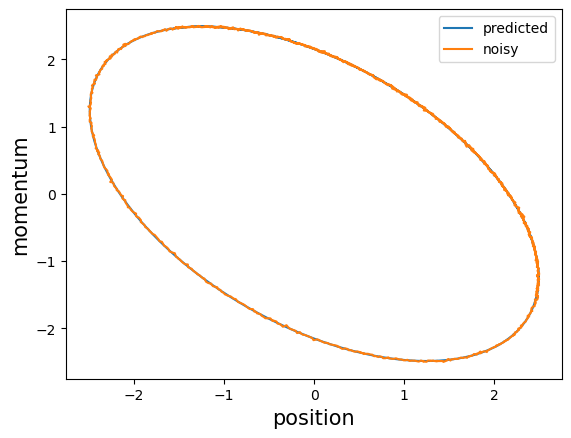

In [37]:
plt.plot(pred_trajs[eval_traj,:,0].detach().numpy(), pred_trajs[eval_traj,:,1].detach().numpy(), label='predicted')
plt.plot(test_noisy[eval_traj,:,0], test_noisy[eval_traj,:,1], label='noisy')
plt.xlabel('position', fontsize=15)
plt.ylabel('momentum', fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='upper right')

In [35]:
t_fut = 0

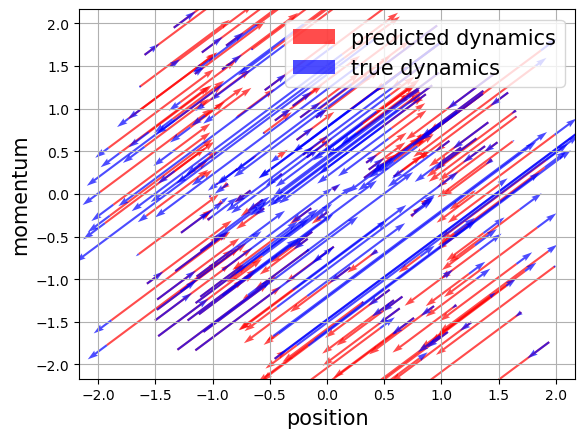

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Example vectors
#a = np.array([1, 2, 3])
#b = np.array([4, 5, 6])
num_pts = 200

# Create a figure and axis
fig, ax = plt.subplots()

# Plot arrows using quiver
# a, b are the starting points, and a, b are the directions
#ax.quiver(test[0:num_pts, t_fut, 0], test[0:num_pts, t_fut, 1], pred_dyn_np_fut[0:num_pts, 0], pred_dyn_np_fut[0:num_pts, 1], angles='xy', scale_units='xy', scale=2, color='r', label="predicted dynamics", alpha =0.7)
#ax.quiver(test[0:num_pts, t_fut, 0], test[0:num_pts, t_fut, 1], true_dyn_np_fut[0:num_pts, 0], true_dyn_np_fut[0:num_pts, 1], angles='xy', scale_units='xy', scale=2, color='b', label="true dynamics", alpha =0.7)

ax.quiver(test[0:num_pts, t_fut, 0], test[0:num_pts, t_fut, 1], pred_dyn_np_fut[0:num_pts, 0], pred_dyn_np_fut[0:num_pts, 0], angles='xy', scale_units='xy', scale=2, color='r', label="predicted dynamics", alpha =0.7)
ax.quiver(test[0:num_pts, t_fut, 0], test[0:num_pts, t_fut, 1], true_dyn_np_fut[0:num_pts, 1], true_dyn_np_fut[0:num_pts, 1], angles='xy', scale_units='xy', scale=2, color='b', label="true dynamics", alpha =0.7)


# Set the limits of the plot
ax.set_xlim(torch.min(test[0:num_pts,:, 0]) - 0.2*torch.mean(test[0:num_pts,:, 1]),  torch.max(test[0:num_pts,:, 0]) + 0.2*torch.mean(test[0:num_pts,:, 1]))
ax.set_ylim(torch.min(test[0:num_pts,:, 0]) - 0.2*torch.mean(test[0:num_pts,:, 1]),  torch.max(test[0:num_pts,:, 0]) + 0.2*torch.mean(test[0:num_pts,:, 1]))

# Adding labels and title
#plt.title('Arrows Plot')
plt.xlabel('position', fontsize=15)
plt.ylabel('momentum', fontsize=15)

# Show grid
plt.grid(True)
plt.legend(fontsize=15)

# Show the plot
plt.show()

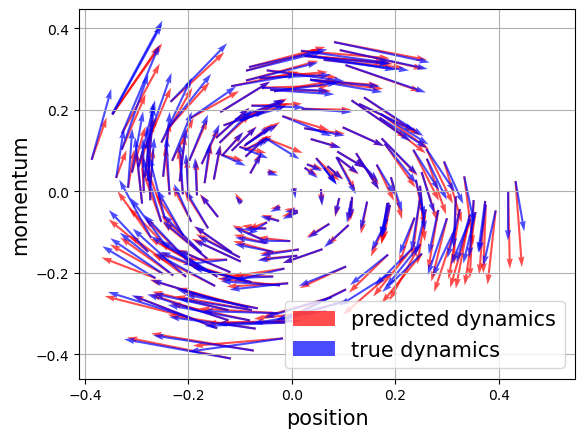

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Example vectors
#a = np.array([1, 2, 3])
#b = np.array([4, 5, 6])
num_pts = 200

# Create a figure and axis
fig, ax = plt.subplots()

# Plot arrows using quiver
# a, b are the starting points, and a, b are the directions
#ax.quiver(test[0:num_pts, t_fut, 0], test[0:num_pts, t_fut, 1], pred_dyn_np_fut[0:num_pts, 0], pred_dyn_np_fut[0:num_pts, 1], angles='xy', scale_units='xy', scale=2, color='r', label="predicted dynamics", alpha =0.7)
#ax.quiver(test[0:num_pts, t_fut, 0], test[0:num_pts, t_fut, 1], true_dyn_np_fut[0:num_pts, 0], true_dyn_np_fut[0:num_pts, 1], angles='xy', scale_units='xy', scale=2, color='b', label="true dynamics", alpha =0.7)

ax.quiver(test[0:num_pts, t_fut, 1], test[0:num_pts, t_fut, 3], pred_dyn_np_fut[0:num_pts, 1], pred_dyn_np_fut[0:num_pts, 3], angles='xy', scale_units='xy', scale=2, color='r', label="predicted dynamics", alpha =0.7)
ax.quiver(test[0:num_pts, t_fut, 1], test[0:num_pts, t_fut, 3], true_dyn_np_fut[0:num_pts, 1], true_dyn_np_fut[0:num_pts, 3], angles='xy', scale_units='xy', scale=2, color='b', label="true dynamics", alpha =0.7)


# Set the limits of the plot
ax.set_xlim(torch.min(test[0:num_pts,:, 1]) - 0.2*torch.mean(test[0:num_pts,:, 1]),  torch.max(test[0:num_pts,:, 1]) + 0.2*torch.mean(test[0:num_pts,:, 1]))
ax.set_ylim(torch.min(test[0:num_pts,:, 3]) - 0.2*torch.mean(test[0:num_pts,:, 3]),  torch.max(test[0:num_pts,:, 3]) + 0.2*torch.mean(test[0:num_pts,:, 3]))

# Adding labels and title
#plt.title('Arrows Plot')
plt.xlabel('position', fontsize=15)
plt.ylabel('momentum', fontsize=15)

# Show grid
plt.grid(True)
plt.legend(fontsize=15)

# Show the plot
plt.show()

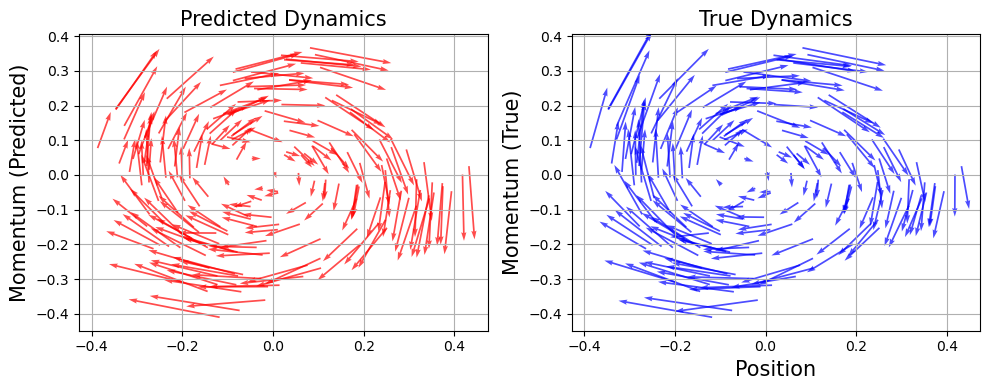

In [103]:
num_pts = 200

# Create figure with two subplots sharing the x-axis
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - Predicted dynamics
axes[0].quiver(
    test[0:num_pts, t_fut, 1], test[0:num_pts, t_fut, 3], 
    pred_dyn_np_fut[0:num_pts, 1], pred_dyn_np_fut[0:num_pts, 3], 
    angles='xy', scale_units='xy', scale=2, color='r', alpha=0.7
)
axes[0].set_ylabel("Momentum (Predicted)", fontsize=15)
axes[0].set_title("Predicted Dynamics", fontsize=15)
axes[0].grid(True)

# Second subplot - True dynamics
axes[1].quiver(
    test[0:num_pts, t_fut, 1], test[0:num_pts, t_fut, 3], 
    true_dyn_np_fut[0:num_pts, 1], true_dyn_np_fut[0:num_pts, 3], 
    angles='xy', scale_units='xy', scale=2, color='b', alpha=0.7
)
axes[1].set_xlabel("Position", fontsize=15)
axes[1].set_ylabel("Momentum (True)", fontsize=15)
axes[1].set_title("True Dynamics", fontsize=15)
axes[1].grid(True)

# Adjust layout and show
plt.tight_layout()
plt.show()

In [128]:
print(torch.min(test_noisy[:,:,0]), torch.max(test_noisy[:,:,0]))
print(torch.min(test_noisy[:,:,1]), torch.max(test_noisy[:,:,1]))
print(torch.min(test_noisy[:,:,2]), torch.max(test_noisy[:,:,2]))
print(torch.min(test_noisy[:,:,3]), torch.max(test_noisy[:,:,3]))

tensor(-0.6719) tensor(0.6013)
tensor(-0.4767) tensor(0.6043)
tensor(-0.5646) tensor(0.5205)
tensor(-0.4798) tensor(0.4954)


In [44]:
num_pts=30
# Define grid
#q_vals = np.linspace(torch.min(test_noisy[:,:,0]), torch.max(test_noisy[:,:,0]), num_pts)
#p_vals = np.linspace(torch.min(test_noisy[:,:,0]), torch.max(test_noisy[:,:,0]), num_pts)
q_vals = np.linspace(-3, 3, num_pts)
p_vals = np.linspace(-3, 3, num_pts)
Q, P = np.meshgrid(q_vals, p_vals)

In [45]:
Y = torch.tensor([Q[0], P[0]], dtype=torch.float32).T
Y.shape

torch.Size([30, 2])

In [46]:
args = None

In [47]:
# pred_dyn_q = np.zeros((num_pts, num_pts))
# pred_dyn_p = np.zeros((num_pts, num_pts))
# true_dyn_q = np.zeros((num_pts, num_pts))
# true_dyn_p = np.zeros((num_pts, num_pts))
# for i in range(Q.shape[1]):
#     pred_dyn = forward_ode(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, (model,), (0,)).detach().numpy()
#     pred_dyn_q[i,:] = pred_dyn[:,0]
#     pred_dyn_p[i,:] = pred_dyn[:,1]
#     true_dyn = coupled_ho(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, args, None).detach().numpy()
#     true_dyn = coupled_ho(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, args, None).detach().numpy()
#     true_dyn_q[i,:] = true_dyn[:,0]
#     true_dyn_p[i,:] = true_dyn[:,1]

In [48]:
# # Compute error
# grad_mag_diff = np.sqrt((true_dyn_q - pred_dyn_q)**2 + (true_dyn_p - pred_dyn_p)**2)
# dq_error = true_dyn_q - pred_dyn_q
# dp_error = true_dyn_p - pred_dyn_p

In [49]:
# # Plot results
# fig, axs = plt.subplots(2, 2, figsize=(8, 8))
# scale_factor=30

# #  Side-by-side quiver plots (true vs. numerical)
# axs[0, 0].quiver(Q, P, true_dyn_q, true_dyn_p, color='blue', scale=scale_factor, alpha=0.6, label="True")
# axs[0, 0].set_title("True Hamiltonian vector Field")
# axs[0, 1].quiver(Q, P, pred_dyn_q, pred_dyn_p, color='red', scale=scale_factor, alpha=0.6, label="Numerical")
# axs[0, 1].set_title("Predicted Hamiltonian vector Field")
# #  Heatmap of gradient magnitude difference
# c = axs[1, 0].imshow(grad_mag_diff, extent=[-2*np.pi, 2*np.pi, -2*np.pi, 2*np.pi], origin="lower", cmap="magma")
# plt.colorbar(c, ax=axs[1, 0])
# axs[1, 0].set_title("Gradient Magnitude Difference")

# #  Quiver plot of difference vector field overlaid on heatmap
# c = axs[1, 1].imshow(grad_mag_diff, extent=[-2*np.pi, 2*np.pi, -2*np.pi, 2*np.pi], origin="lower", cmap="magma")
# axs[1, 1].quiver(Q, P, dq_error, dp_error, color='white', scale=scale_factor, alpha=0.8)
# plt.colorbar(c, ax=axs[1, 1])
# axs[1, 1].set_title("Gradient Difference Vector Field")

# plt.tight_layout()
# plt.show()


In [50]:
#num_pts = 30
pred_dyn_q = np.zeros((num_pts, num_pts))
pred_dyn_p = np.zeros((num_pts, num_pts))
true_dyn_q = np.zeros((num_pts, num_pts))
true_dyn_p = np.zeros((num_pts, num_pts))
pred_h = np.zeros((num_pts, num_pts))
true_h = np.zeros((num_pts, num_pts))
for i in range(Q.shape[1]):
    #pred_dyn = forward_ode(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, (model,), (0,)).detach().numpy()
    pred_dyn = forward_ode(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, (model,), (0,)).detach().numpy()
    pred_dyn_q[i,:] = pred_dyn[:,0]
    pred_dyn_p[i,:] = pred_dyn[:,1]
    #true_dyn = mass_spring(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, args, None).detach().numpy()
    
    #Coupled HO
    #args = alpha
    #true_dyn = coupled_ho(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, args, None).detach().numpy()
    #true_h[i,:] = Q[i,:]**2 + P[i,:]**2 + alpha*Q[i,:]*P[i,:]
    
    #Double Well
    true_dyn = double_well(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T, None, None).detach().numpy()
    true_h[i,:] = (0.5*(P[i,:]**2) + 0.25*(Q[i,:]**4) - 0.5*(Q[i,:]**2))

    pred_h[i,:] = model(torch.tensor([Q[i,:],P[i,:]], dtype=torch.float32).T).squeeze().detach().numpy() - offset
    true_dyn_q[i,:] = true_dyn[:,0]
    true_dyn_p[i,:] = true_dyn[:,1]

In [51]:
# Compute error
h_diff = true_h - pred_h
dq_error = true_dyn_q - pred_dyn_q
dp_error = true_dyn_p - pred_dyn_p

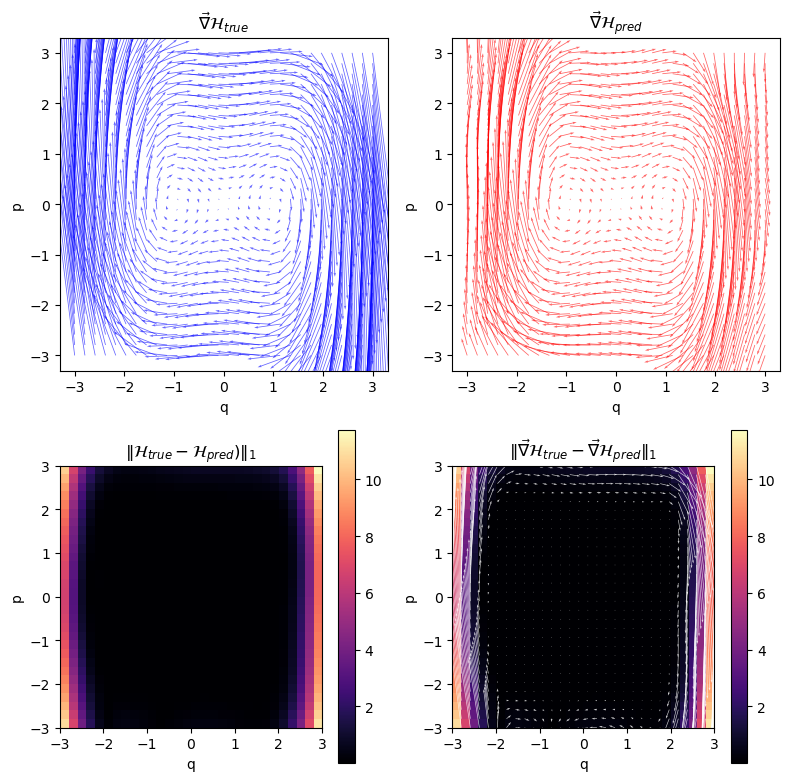

In [54]:
# Plot results
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
scale_factor=30

#  Side-by-side quiver plots (true vs. numerical)
axs[0, 0].quiver(Q, P, true_dyn_q, true_dyn_p, color='blue', scale=scale_factor, alpha=0.6, label="True")
axs[0, 0].set_title(r'$\vec\nabla\mathcal{H}_{true}$')
axs[0, 0].set_xlabel('q')
axs[0, 0].set_ylabel('p')
axs[0, 1].quiver(Q, P, pred_dyn_q, pred_dyn_p, color='red', scale=scale_factor, alpha=0.6, label="Numerical")
axs[0, 1].set_title(r'$\vec\nabla\mathcal{H}_{pred}$')
axs[0, 1].set_xlabel('q')
axs[0, 1].set_ylabel('p')
#  Heatmap of gradient magnitude difference
c = axs[1, 0].imshow(np.abs(h_diff), extent=[-3, 3, -3, 3], origin="lower", cmap="magma")
plt.colorbar(c, ax=axs[1, 0])
axs[1, 0].set_title(r'$\|\mathcal{H}_{true} - \mathcal{H}_{pred})\|_1$')
axs[1, 0].set_xlabel('q')
axs[1, 0].set_ylabel('p')

#  Quiver plot of difference vector field overlaid on heatmap
c = axs[1, 1].imshow(np.abs(h_diff), extent=[-3, 3, -3, 3], origin="lower", cmap="magma")
axs[1, 1].quiver(Q, P, dq_error, dp_error, color='white', scale=scale_factor, alpha=0.8)
axs[1, 1].set_xlabel('q')
axs[1, 1].set_ylabel('p')
plt.colorbar(c, ax=axs[1, 1])
axs[1, 1].set_title(r'$\|\vec\nabla\mathcal{H}_{true} - \vec \nabla\mathcal{H}_{pred}\|_1$')

plt.tight_layout()
plt.show()


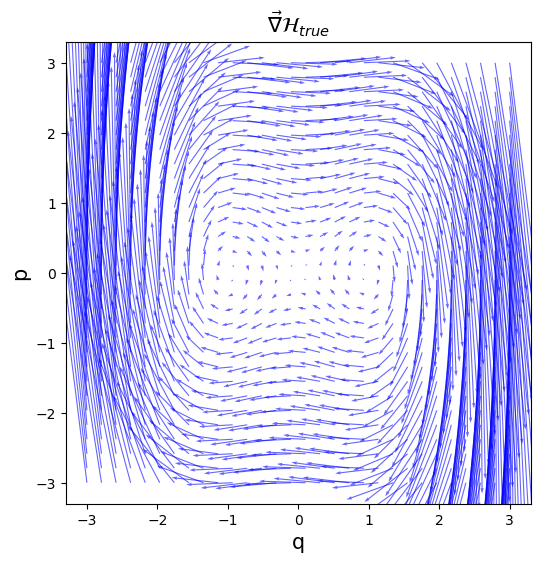

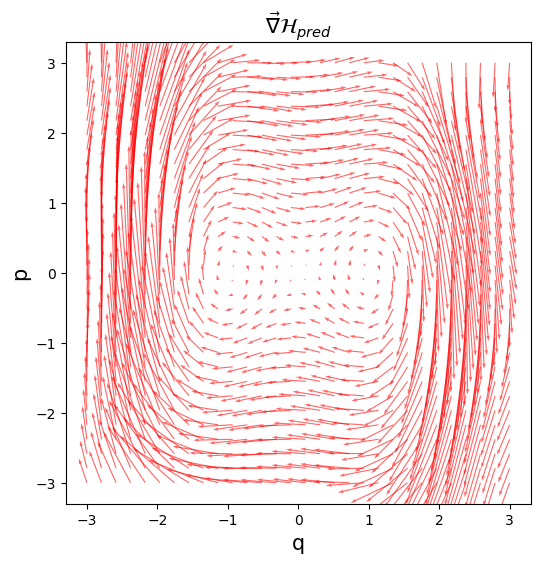

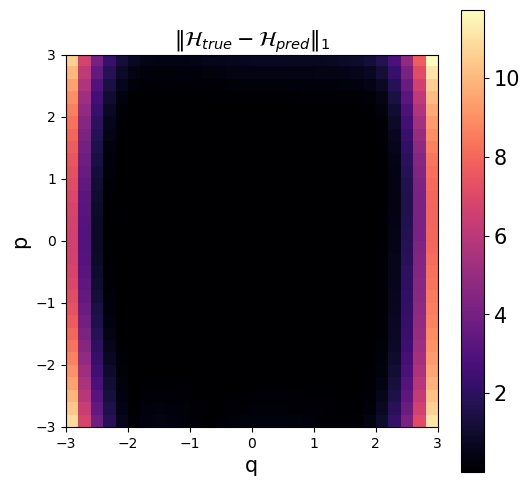

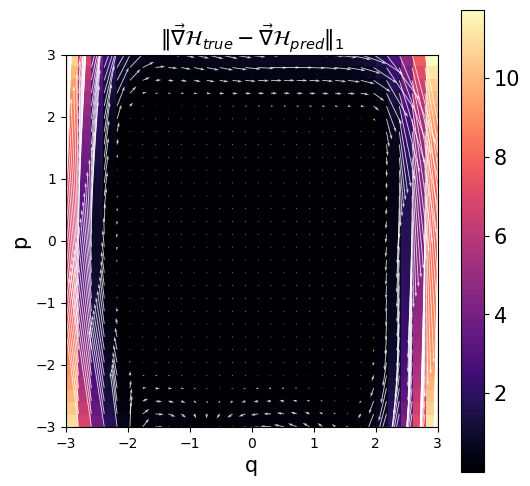

In [56]:
import matplotlib.pyplot as plt
import numpy as np

scale_factor = 30

# Figure 1: True gradient field
fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.quiver(Q, P, true_dyn_q, true_dyn_p, color='blue', scale=scale_factor, alpha=0.6, label="True")
ax1.set_title(r'$\vec\nabla\mathcal{H}_{true}$', fontsize=15)
ax1.set_xlabel('q', fontsize=15)
ax1.set_ylabel('p', fontsize=15)
plt.show()

# Figure 2: Predicted gradient field
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.quiver(Q, P, pred_dyn_q, pred_dyn_p, color='red', scale=scale_factor, alpha=0.6, label="Numerical")
ax2.set_title(r'$\vec\nabla\mathcal{H}_{pred}$', fontsize=15)
ax2.set_xlabel('q', fontsize=15)
ax2.set_ylabel('p', fontsize=15)
plt.show()

# Figure 3: Heatmap of gradient magnitude difference
fig3, ax3 = plt.subplots(figsize=(6, 6))
c = ax3.imshow(np.abs(h_diff), extent=[-3, 3, -3, 3], origin="lower", cmap="magma")
plt.colorbar(c, ax=ax3).ax.tick_params(labelsize=15)  # Set fontsize for colorbar
ax3.set_title(r'$\|\mathcal{H}_{true} - \mathcal{H}_{pred}\|_1$', fontsize=15)
ax3.set_xlabel('q', fontsize=15)
ax3.set_ylabel('p', fontsize=15)
plt.show()

# Figure 4: Quiver plot of difference vector field overlaid on heatmap
fig4, ax4 = plt.subplots(figsize=(6, 6))
c = ax4.imshow(np.abs(h_diff), extent=[-3, 3, -3, 3], origin="lower", cmap="magma")
ax4.quiver(Q, P, dq_error, dp_error, color='white', scale=scale_factor, alpha=0.8)
plt.colorbar(c, ax=ax4).ax.tick_params(labelsize=15)  # Set fontsize for colorbar
ax4.set_xlabel('q', fontsize=15)
ax4.set_ylabel('p', fontsize=15)
ax4.set_title(r'$\|\vec\nabla\mathcal{H}_{true} - \vec \nabla\mathcal{H}_{pred}\|_1$', fontsize=15)
plt.show()


In [51]:
num_pts = 20
# Extract min/max values from the dataset
q1_min, q1_max = torch.min(test_noisy[:,:,0]), torch.max(test_noisy[:,:,0])
p1_min, p1_max = torch.min(test_noisy[:,:,2]), torch.max(test_noisy[:,:,2])
q2_min, q2_max = torch.min(test_noisy[:,:,1]), torch.max(test_noisy[:,:,1])
p2_min, p2_max = torch.min(test_noisy[:,:,3]), torch.max(test_noisy[:,:,3])

# Create 1D grids
q_vals_1 = np.linspace(q1_min, q1_max, num_pts)
p_vals_1 = np.linspace(p1_min, p1_max, num_pts)
q_vals_2 = np.linspace(q2_min, q2_max, num_pts)
p_vals_2 = np.linspace(p2_min, p2_max, num_pts)

# Create a full 4D meshgrid
Q1, P1, Q2, P2 = np.meshgrid(q_vals_1, p_vals_1, q_vals_2, p_vals_2, indexing='ij')

# The resulting arrays are 4D tensors of shape (num_pts, num_pts, num_pts, num_pts)
print(Q1.shape, P1.shape, Q2.shape, P2.shape)  # Should print (num_pts, num_pts, num_pts, num_pts)


(20, 20, 20, 20) (20, 20, 20, 20) (20, 20, 20, 20) (20, 20, 20, 20)


In [52]:
print(q1_min, q1_max)

tensor(-0.6719) tensor(0.6013)


In [53]:
pred_dyn_q1 = np.zeros((num_pts, num_pts, num_pts, num_pts))
pred_dyn_q2 = np.zeros((num_pts, num_pts, num_pts, num_pts))
pred_dyn_p1 = np.zeros((num_pts, num_pts, num_pts, num_pts))
pred_dyn_p2 = np.zeros((num_pts, num_pts, num_pts, num_pts))
true_dyn_q1 = np.zeros((num_pts, num_pts, num_pts, num_pts))
true_dyn_q2 = np.zeros((num_pts, num_pts, num_pts, num_pts))
true_dyn_p1 = np.zeros((num_pts, num_pts, num_pts, num_pts))
true_dyn_p2 = np.zeros((num_pts, num_pts, num_pts, num_pts))
true_h = np.zeros((num_pts, num_pts, num_pts, num_pts))
pred_h = np.zeros((num_pts, num_pts, num_pts, num_pts))

for i in range(num_pts):
    for j in range(num_pts):
        for k in range(num_pts):
            for l in range(num_pts):
                 
                q1 = q_vals_1[i]
                q2 = q_vals_2[j]
                p1 = p_vals_1[k]
                p2 = p_vals_2[l]

                state = torch.tensor([[q1, q2, p1, p2]], dtype=torch.float32)
                # Predicted dynamics using the learned model
                pred_dyn = forward_ode(state, (model,), (0,)).detach().numpy()

                pred_dyn_q1[i, j, k, l] = pred_dyn[:, 0]
                pred_dyn_q2[i, j, k, l] = pred_dyn[:, 1]
                pred_dyn_p1[i, j, k, l] = pred_dyn[:, 2]
                pred_dyn_p2[i, j, k, l] = pred_dyn[:, 3]

                # True dynamics
                true_dyn = henon_heiles(state, None, None).detach().numpy()
                true_dyn_q1[i, j, k, l] = true_dyn[:, 0]
                true_dyn_q2[i, j, k, l] = true_dyn[:, 1]
                true_dyn_p1[i, j, k, l] = true_dyn[:, 2]
                true_dyn_p2[i, j, k, l] = true_dyn[:, 3]

                # Hamiltonian values
                true_h[i, j, k, l] = (0.5*(p1**2 + p2**2) + 0.5*(q1**2 + q2**2) + (q1**2)*(q2) - ((q2**3)/3))
                pred_h[i, j, k, l] = model(state).squeeze().detach().numpy() - offset


In [54]:
# Compute error
h_diff = true_h - pred_h
error_dyn_q = true_dyn_q2 - pred_dyn_q2
error_dyn_p = true_dyn_p2 - true_dyn_p2

In [56]:
ind_q1 = 10
ind_p1 = 10

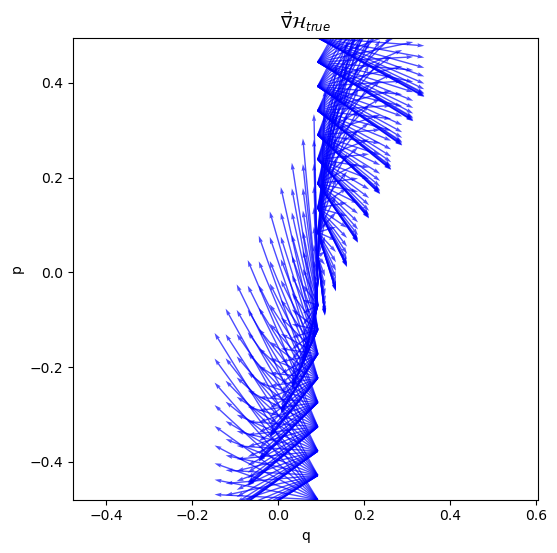

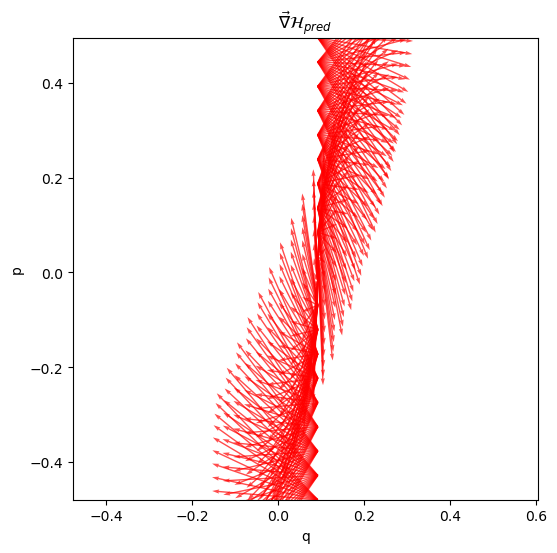

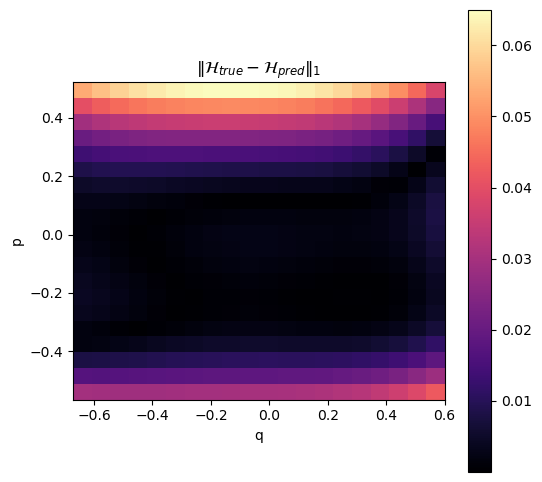

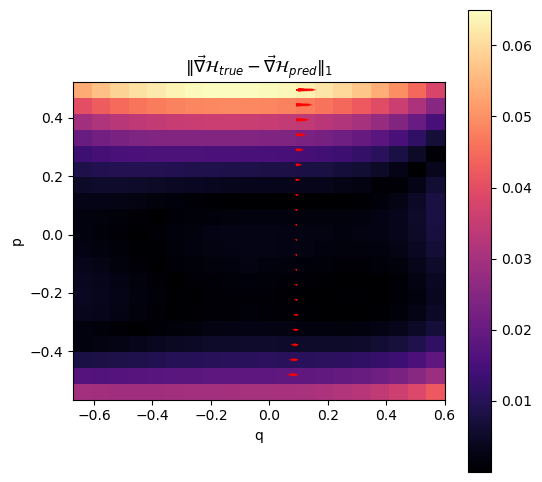

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

scale_factor = 30

# True dynamics quiver plot
plt.figure(figsize=(6, 6))
plt.quiver(Q2[ind_q1, :, ind_p1, :], P2[ind_q1, :, ind_p1, :], 
           true_dyn_q2[ind_q1, :, ind_p1, :], true_dyn_p2[ind_q1, :, ind_p1, :], 
           angles='xy', scale_units='xy', scale=2, color='b', alpha=0.7)
plt.xlim(q2_min, q2_max)
plt.ylim(p2_min, p2_max)
plt.xlabel(r'$q_y$')
plt.ylabel(r'$p_y$')
plt.title(r'$\vec\nabla\mathcal{H}_{true}$')
plt.show()

# Predicted dynamics quiver plot
plt.figure(figsize=(6, 6))
plt.quiver(Q2[ind_q1, :, ind_p1, :], P2[ind_q1, :, ind_p1, :], 
           pred_dyn_q2[ind_q1, :, ind_p1, :], pred_dyn_p2[ind_q1, :, ind_p1, :], 
           angles='xy', scale_units='xy', scale=2, color='r', alpha=0.7)
plt.xlim(q2_min, q2_max)
plt.ylim(p2_min, p2_max)
plt.xlabel(r'$q_y$')
plt.ylabel(r'$p_y$')
plt.title(r'$\vec\nabla\mathcal{H}_{pred}$')
plt.show()

# Heatmap of gradient magnitude difference
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(h_diff[ind_q1, :, ind_p1, :]), extent=[q1_min, q1_max, p1_min, p1_max], 
           origin="lower", cmap="magma")
plt.colorbar()
plt.xlabel(r'$q_y$')
plt.ylabel(r'$p_y$')
plt.title(r'$\| \mathcal{H}_{true} - \mathcal{H}_{pred} \|_1$')
plt.show()

# Quiver plot of error dynamics overlaid on heatmap
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(h_diff[ind_q1, :, ind_p1, :]), extent=[q1_min, q1_max, p1_min, p1_max], 
           origin="lower", cmap="magma")
plt.colorbar()
plt.quiver(Q2[ind_q1, :, ind_p1, :], P2[ind_q1, :, ind_p1, :], 
           error_dyn_q[ind_q1, :, ind_p1, :], error_dyn_p[ind_q1, :, ind_p1, :], 
           angles='xy', scale_units='xy', scale=2, color='r', alpha=0.7)
plt.xlabel(r'$q_y$')
plt.ylabel(r'$p_y$')
plt.title(r'$\|\vec\nabla\mathcal{H}_{true} - \vec\nabla\mathcal{H}_{pred}\|_1$')
plt.show()


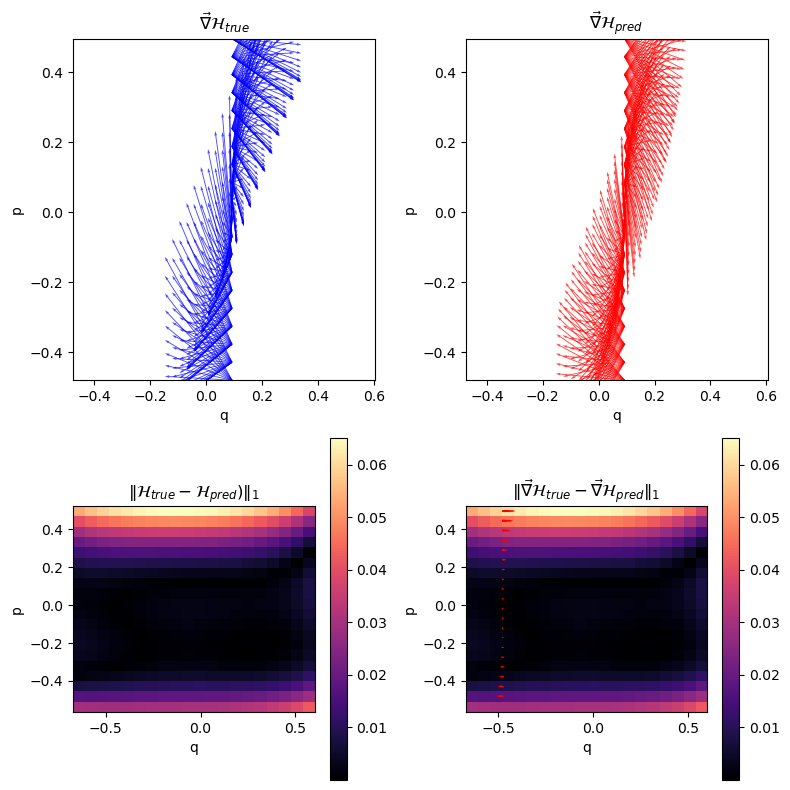

In [107]:
# Plot results
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
scale_factor=30

#  Side-by-side quiver plots (true vs. numerical)
axs[0, 0].quiver(Q2[ind_q1,:,ind_p1,:], P2[ind_q1,:,ind_p1,:], true_dyn_q2[ind_q1,:,ind_p1,:], true_dyn_p2[ind_q1,:,ind_p1,:], angles='xy', scale_units='xy', scale=2, color='b', label="true dynamics", alpha =0.7)

# Set the limits of the plot
axs[0, 0].set_xlim(q2_min, q2_max)
axs[0, 0].set_ylim(p2_min, p2_max)
#axs[0, 0].quiver(Q2[fixed_q1_index,:,fixed_p1_index,:], P2[fixed_q1_index,:,fixed_p1_index,:], true_dyn_q, true_dyn_p, color='blue', scale=scale_factor, alpha=0.6, label="True")
axs[0, 0].set_title(r'$\vec\nabla\mathcal{H}_{true}$')
axs[0, 0].set_xlabel('q')
axs[0, 0].set_ylabel('p')

axs[0, 1].quiver(Q2[ind_q1,:,ind_p1,:], P2[ind_q1,:,ind_p1,:], pred_dyn_q2[ind_q1,:,ind_p1,:], pred_dyn_p2[ind_q1,:,ind_p1,:], angles='xy', scale_units='xy', scale=2, color='r', label="predicted dynamics", alpha =0.7)
#axs[0, 1].quiver(Q2[fixed_q1_index,:,fixed_p1_index,:], P2[fixed_q1_index,:,fixed_p1_index,:], pred_dyn_q, pred_dyn_p, color='red', scale=scale_factor, alpha=0.6, label="Numerical")
axs[0, 1].set_xlim(q2_min, q2_max)
axs[0, 1].set_ylim(p2_min, p2_max)
axs[0, 1].set_title(r'$\vec\nabla\mathcal{H}_{pred}$')
axs[0, 1].set_xlabel('q')
axs[0, 1].set_ylabel('p')
#  Heatmap of gradient magnitude difference

c = axs[1, 0].imshow(np.abs(h_diff[ind_q1,:,ind_p1,:]), extent=[q1_min, q1_max, p1_min, p1_max], origin="lower", cmap="magma")
plt.colorbar(c, ax=axs[1, 0])
axs[1, 0].set_title(r'$\| \mathcal{H}_{true} - \mathcal{H}_{pred}) \|_1$')
axs[1, 0].set_xlabel('q')
axs[1, 0].set_ylabel('p')

#  Quiver plot of difference vector field overlaid on heatmap
c = axs[1, 1].imshow(np.abs(h_diff[ind_q1,:,ind_p1,:]), extent=[q1_min, q1_max, p1_min, p1_max], origin="lower", cmap="magma")
axs[1, 1].quiver(Q2[ind_q1,:,0,:], P2[ind_q1,:,ind_p1,:], error_dyn_q[ind_q1,:,ind_p1,:], error_dyn_p[ind_q1,:,ind_p1,:], angles='xy', scale_units='xy', scale=2, color='r', label="predicted dynamics", alpha =0.7)
#axs[1, 1].quiver(Q2[fixed_q1_index,:,fixed_p1_index,:], P2[fixed_q1_index,:,fixed_p1_index,:], dq_error, dp_error, color='white', scale=scale_factor, alpha=0.8)
axs[1, 1].set_xlabel('q')
axs[1, 1].set_ylabel('p')
plt.colorbar(c, ax=axs[1, 1])
axs[1, 1].set_title(r'$\|\vec\nabla\mathcal{H}_{true} - \vec \nabla\mathcal{H}_{pred}\|_1$')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

scale_factor = 30

# True dynamics quiver plot
plt.figure(figsize=(6, 6))
plt.quiver(Q2[ind_q1, :, ind_p1, :], P2[ind_q1, :, ind_p1, :], 
           true_dyn_q2[ind_q1, :, ind_p1, :], true_dyn_p2[ind_q1, :, ind_p1, :], 
           angles='xy', scale_units='xy', scale=2, color='b', alpha=0.7)
plt.xlim(q2_min, q2_max)
plt.ylim(p2_min, p2_max)
plt.xlabel('q')
plt.ylabel('p')
plt.title(r'$\vec\nabla\mathcal{H}_{true}$')
plt.show()

# Predicted dynamics quiver plot
plt.figure(figsize=(6, 6))
plt.quiver(Q2[ind_q1, :, ind_p1, :], P2[ind_q1, :, ind_p1, :], 
           pred_dyn_q2[ind_q1, :, ind_p1, :], pred_dyn_p2[ind_q1, :, ind_p1, :], 
           angles='xy', scale_units='xy', scale=2, color='r', alpha=0.7)
plt.xlim(q2_min, q2_max)
plt.ylim(p2_min, p2_max)
plt.xlabel('q')
plt.ylabel('p')
plt.title(r'$\vec\nabla\mathcal{H}_{pred}$')
plt.show()

# Heatmap of gradient magnitude difference
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(h_diff[ind_q1, :, ind_p1, :]), extent=[q1_min, q1_max, p1_min, p1_max], 
           origin="lower", cmap="magma")
plt.colorbar()
plt.xlabel('q')
plt.ylabel('p')
plt.title(r'$\| \mathcal{H}_{true} - \mathcal{H}_{pred} \|_1$')
plt.show()

# Quiver plot of error dynamics overlaid on heatmap
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(h_diff[ind_q1, :, ind_p1, :]), extent=[q1_min, q1_max, p1_min, p1_max], 
           origin="lower", cmap="magma")
plt.colorbar()
plt.quiver(Q2[ind_q1, :, ind_p1, :], P2[ind_q1, :, ind_p1, :], 
           error_dyn_q[ind_q1, :, ind_p1, :], error_dyn_p[ind_q1, :, ind_p1, :], 
           angles='xy', scale_units='xy', scale=2, color='r', alpha=0.7)
plt.xlabel('q')
plt.ylabel('p')
plt.title(r'$\


In [61]:
abbr = 'ns'

In [62]:
df = pd.read_csv('/home/choudhar/HNNs/gpu_scripts/output_0_'+abbr+'.csv')

In [63]:
arr = df.values

Text(0, 0.5, 'Loss')

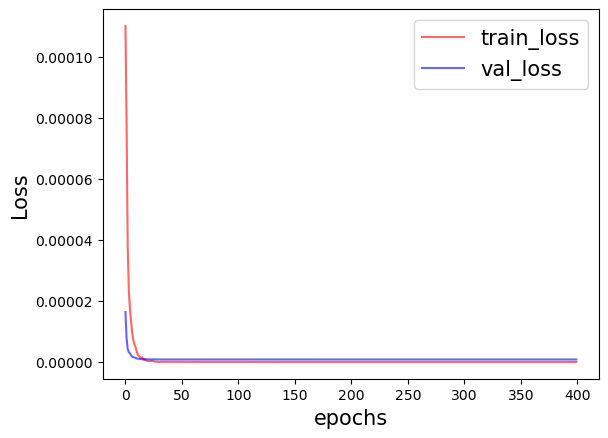

In [64]:
plt.plot(arr[:,0], label = 'train_loss', c='r', alpha=0.6)
plt.plot(arr[:,1], label = 'val_loss', c='b', alpha=0.6)
plt.legend(fontsize=15)
plt.ticklabel_format(axis='y', style='sci')
plt.xlabel('epochs', fontsize=15)
plt.ylabel('Loss', fontsize=15)

Text(0, 0.5, 'Y coordinate')

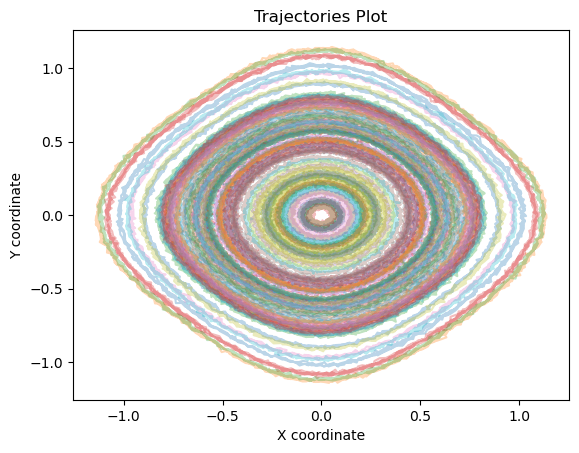

In [65]:
# Create a figure and axis
fig, ax = plt.subplots()

# Loop through each case along dimension 0 and plot the trajectory
for i in range(100):
    ax.plot(test_noisy[i, :, 0], test_noisy[i, :, 1], alpha=0.3)  # alpha for transparency

# Adding labels and title
plt.title('Trajectories Plot')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')

In [168]:
abbr = 'hh'

In [169]:
df1 = pd.read_csv('/home/choudhar/HNNs/gpu_scripts/output_0_'+abbr+'.csv')
df2 = pd.read_csv('/home/choudhar/HNNs/gpu_scripts/output_0_'+abbr+'_adjoint.csv')

In [170]:
arr1 = df1.values
arr2 = df2.values

Text(0, 0.5, 'Loss')

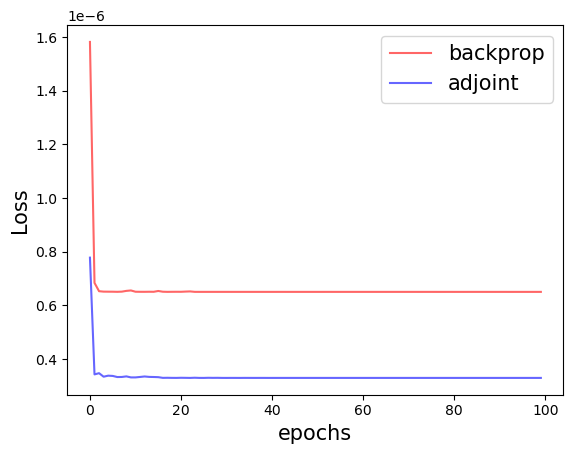

In [171]:
plt.plot(arr1[:,1], label = 'backprop', c='r', alpha=0.6)
plt.plot(arr2[:,1], label = 'adjoint', c='b', alpha=0.6)
plt.legend(fontsize=15)
plt.ticklabel_format(axis='y', style='sci')
plt.xlabel('epochs', fontsize=15)
plt.ylabel('Loss', fontsize=15)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [24]:
adjoint_file = pd.read_csv('adjoint_memory_usage_results_2.csv')
backprop_file = pd.read_csv('backprop_memory_usage_results_2.csv')

In [25]:
memory_usage_adj = adjoint_file['0'].values
run_time_adj = adjoint_file['1'].values

memory_usage_bprop = backprop_file['0'].values
run_time_bprop = backprop_file['1'].values

In [26]:
t_array = np.array([4, 8, 12, 16, 20, 24, 28, 32])

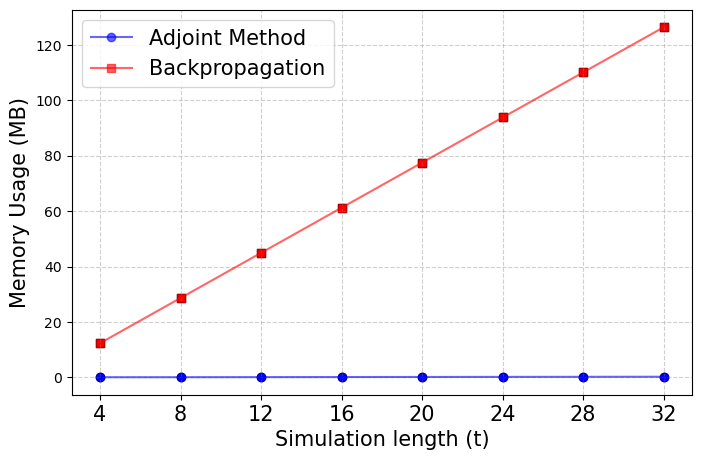

In [32]:
# Create the plot
plt.figure(figsize=(8, 5))

# Line plots
plt.plot(t_array, memory_usage_adj, label="Adjoint Method", color='blue', linestyle='-', marker='o', alpha=0.6)
plt.plot(t_array, memory_usage_bprop, label="Backpropagation", color='red', linestyle='-', marker='s', alpha=0.6)

# Scatter points
plt.scatter(t_array, memory_usage_adj, color='blue', marker='o', edgecolors='black')
plt.scatter(t_array, memory_usage_bprop, color='red', marker='s', edgecolors='black')

# X-axis labels
plt.xticks(t_array, labels=[f"{t}" for t in t_array], fontsize=15)

# Labels and title
plt.xlabel("Simulation length (t)", fontsize = 15)
plt.ylabel("Memory Usage (MB)", fontsize=15)
#plt.title("Memory Usage Comparison: Adjoint vs. Backpropagation")
plt.legend(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

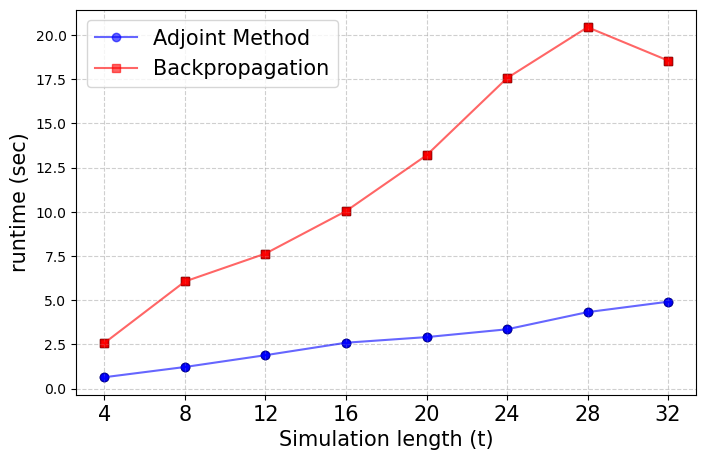

In [34]:
# Create the plot
plt.figure(figsize=(8, 5))

# Line plots
plt.plot(t_array, run_time_adj, label="Adjoint Method", color='blue', linestyle='-', marker='o', alpha=0.6)
plt.plot(t_array, run_time_bprop, label="Backpropagation", color='red', linestyle='-', marker='s', alpha=0.6)

# Scatter points
plt.scatter(t_array, run_time_adj, color='blue', marker='o', edgecolors='black')
plt.scatter(t_array, run_time_bprop, color='red', marker='s', edgecolors='black')

# X-axis labels
plt.xticks(t_array, labels=[f"{t}" for t in t_array], fontsize=15)

# Labels and title
plt.xlabel("Simulation length (t)", fontsize = 15)
plt.ylabel("runtime (sec)", fontsize=15)
#plt.title("Memory Usage Comparison: Adjoint vs. Backpropagation")
plt.legend(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()